In [4]:
import os
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import scipy.integrate as scint
import scipy.optimize as sciop
import astropy.cosmology as apcosm

cosmo = apcosm.Planck18

In [8]:
# Select source type and detection thresold
CBC_type = 'BBH'  
snr_lo = 12

data_paths = {
    'BBH':  '/ligo/home/ligo.org/shiksha.pandey/ce_stm/bbh/gwfast_results.hdf5',
    'NSBH': '/ligo/home/ligo.org/shiksha.pandey/ce_stm/nsbh/gwfast_results.hdf5',
    'BNS':  '/ligo/home/ligo.org/shiksha.pandey/ce_stm/bns/gwfast_results.hdf5',
}
full_data_path = data_paths[CBC_type]

outdir = os.path.dirname(full_data_path) + '/figures/'
os.makedirs(outdir, exist_ok=True)

# Detector networks
networks = ['ET_CE20', 'ET_CE40', 'LIO_CE40_ET', 'LIO_CE40_CE20', 'HLIs']

# Plot style
plot_colors = ['#105f47', '#d95f02', '#7570b3', '#e7298a', '#66a61e']
lss = ['-', '--', (0, (3, 1, 1, 1)), (0, (1, 1)), ':']
net_labs = [
    r'ET+CE20',
    r'ET+CE40',
    r'LIO+CE40+ET',
    r'LIO+CE40+CE20',
    r'HLIs',
]

# Injection parameter keys
params = ['DL', 'Mc', 'eta', 'm1', 'm2', 'z', 'dec', 'ra', 'psi',
          'tGPS', 'phic', 'log_DL', 'log_Mc', 'chi1z', 'chi2z']
if CBC_type == 'BBH':
    params += ['iota', 'thetaJN', 'chi1', 'chi2', 'tilt1', 'tilt2', 'phiJL', 'phi12']
elif CBC_type == 'NSBH':
    params += ['iota']

# Data keys within network
net_data = ['chi1z', 'chi2z', 'dec', 'eta', 'iota', 'log_DL', 'log_Mc',
            'phic', 'psi', 'ra', 'sky_area_90', 'tc', 'snr',
            'inv_cond', 'cond_num', 'inv_err', 'cov_Mc_eta']
if CBC_type == 'BBH':
    net_data += ['chi1x', 'chi2x', 'chi1y', 'chi2y']
elif CBC_type in ('NSBH', 'BNS'):
    net_data += ['LambdaTilde', 'deltaLambda']

**Helper Functions**

In [ ]:
def err_m1m2_from_mceta(errMC, errETA, MC, ETA, cov):
    """ Convert (Mc, eta) errors to (m1, m2) errors via Jacobian propagation"""
    dm1_dMc = 0.5 * ETA**(-3./5.) * (1 + np.sqrt(1 - 4*ETA))
    dm2_dMc = 0.5 * ETA**(-3./5.) * (1 - np.sqrt(1 - 4*ETA))
    dm1_eta = -(3./10.) * MC * ETA**(-8./5.) * (1 + np.sqrt(1 - 4*ETA)) \
              - MC * ETA**(-3./5.) / np.sqrt(1 - 4*ETA)
    dm2_eta = -(3./10.) * MC * ETA**(-8./5.) * (1 - np.sqrt(1 - 4*ETA)) \
              + MC * ETA**(-3./5.) / np.sqrt(1 - 4*ETA)
    err_m1 = np.sqrt(dm1_dMc**2 * errMC**2 + dm1_eta**2 * errETA**2 + 2*dm1_dMc * dm1_eta * cov)
    err_m2 = np.sqrt(dm2_dMc**2 * errMC**2 + dm2_eta**2 * errETA**2 + 2*dm2_dMc * dm2_eta * cov)
    return err_m1, err_m2

def get_log_binning_for_sample(data_sample, ndata_bins):
    """ Create log-spaced bin edges and midpoints for a data sample"""
    bin_e = np.logspace(np.log10(np.amin(data_sample)), np.log10(np.amax(data_sample)), ndata_bins)
    bin_m = 10**((np.log10(bin_e)[1:] + np.log10(bin_e)[:-1]) / 2)
    return bin_e, bin_m

# # Rate functions
# def md_merger_rate(z, gamma=2.7, kappa=5.6, z_p=1.9, phi0=1):
#     return phi0 * (1+z)**gamma / (1+((1+z)/(1+z_p))**kappa)

# def md_rate_per_yr_up_to_intgnd(zz):
#     return (md_merger_rate(zz) / md_merger_rate(0) / (1+zz) * 4 * np.pi *
#             cosmo.differential_comoving_volume(zz) / 1000**3).value

# def md_rate_per_yr_up_to(z, zmin=0):
#     return scint.quad(md_rate_per_yr_up_to_intgnd, zmin, z)[0]

**Loading Data**

In [10]:
print(f'Loading {full_data_path}')

full_params = {}
with h5py.File(full_data_path, 'r') as fi:
    print(f'inj_params keys: {sorted(fi["inj_params"].keys())}')
    print(f'network keys: {sorted(fi["networks"].keys())}')

    for net in networks:
        full_params[net] = {'inj_params': {}, 'net_data': {}}
        for p in params:
            if p in fi['inj_params']:
                full_params[net]['inj_params'][p] = fi['inj_params'][p][:]
        for d in net_data:
            if d in fi['networks'][net]:
                full_params[net]['net_data'][d] = fi['networks'][net][d][:]

num_inj = len(full_params[networks[0]]['inj_params']['z'])
print(f'Total events: {num_inj}')

Loading /ligo/home/ligo.org/shiksha.pandey/ce_stm/bbh/gwfast_results.hdf5
inj_params keys: ['DL', 'DL_Mpc', 'Mc', 'chi1', 'chi1z', 'chi2', 'chi2z', 'dec', 'eta', 'log_DL', 'log_Mc', 'm1', 'm1_src', 'm2', 'm2_src', 'phi', 'phi12', 'phiJL', 'phic', 'psi', 'ra', 'tGPS', 'theta', 'thetaJN', 'tilt1', 'tilt2', 'z']
network keys: ['ET_CE20', 'ET_CE40', 'HLIs', 'LIO_CE40_CE20', 'LIO_CE40_ET']
Total events: 27929


**Per-network detections**

In [11]:
# SNR>= threshold, inv_cond == 1, log_Mc > 0, and np.isinfinite(log_Mc) select valid detected events
det_ids = {}
for net in networks:
    snr = full_params[net]['net_data']['snr']
    ic = full_params[net]['net_data']['inv_cond']
    log_Mc = full_params[net]['net_data']['log_Mc']
    mask = (snr >= snr_lo) & (ic == 1) & (log_Mc > 0) & np.isfinite(log_Mc)
    det_ids[net] = np.where(mask)[0]
    print(f'{net}: {len(det_ids[net])} detected (SNR>={snr_lo}, valid errors)')

ET_CE20: 25475 detected (SNR>=12, valid errors)
ET_CE40: 26857 detected (SNR>=12, valid errors)
LIO_CE40_ET: 26870 detected (SNR>=12, valid errors)
LIO_CE40_CE20: 26312 detected (SNR>=12, valid errors)
HLIs: 1960 detected (SNR>=12, valid errors)


**Extract Arrays**

In [12]:
# Per-network error arrays for detected events
snr_pop = {net: full_params[net]['net_data']['snr'][det_ids[net]] for net in networks}
logMc_pop = {net: full_params[net]['net_data']['log_Mc'][det_ids[net]] for net in networks}
logDL_pop = {net: full_params[net]['net_data']['log_DL'][det_ids[net]] for net in networks}
sa90_pop = {net: full_params[net]['net_data']['sky_area_90'][det_ids[net]] for net in networks}
erreta_pop = {net: full_params[net]['net_data']['eta'][det_ids[net]] for net in networks}
erriota_pop = {net: full_params[net]['net_data']['iota'][det_ids[net]] for net in networks}
errchi1z_pop = {net: full_params[net]['net_data']['chi1z'][det_ids[net]] for net in networks}
errchi2z_pop = {net: full_params[net]['net_data']['chi2z'][det_ids[net]] for net in networks}
cov_Mc_eta_pop = {net: full_params[net]['net_data']['cov_Mc_eta'][det_ids[net]] for net in networks}

if CBC_type in ('NSBH', 'BNS'):
    errLambdaTilde_pop = {net: full_params[net]['net_data']['LambdaTilde'][det_ids[net]] for net in networks}
    errdeltaLambda_pop = {net: full_params[net]['net_data']['deltaLambda'][det_ids[net]] for net in networks}

# Per-network injection values for detected events
Mc_inj = {net: full_params[net]['inj_params']['Mc'][det_ids[net]] for net in networks}
eta_inj = {net: full_params[net]['inj_params']['eta'][det_ids[net]] for net in networks}
m1_inj = {net: full_params[net]['inj_params']['m1'][det_ids[net]] for net in networks}
m2_inj = {net: full_params[net]['inj_params']['m2'][det_ids[net]] for net in networks}
z_inj = {net: full_params[net]['inj_params']['z'][det_ids[net]] for net in networks}
DL_inj = {net: full_params[net]['inj_params']['DL'][det_ids[net]] for net in networks}

In [13]:
# Computing fractional mass errors
errMC_pop = {net: logMc_pop[net] * Mc_inj[net] for net in networks}

errm1 = {}; errm2 = {}; frac_errm1 = {}; frac_errm2 = {}
for net in networks:
    em1, em2 = err_m1m2_from_mceta(
        errMC_pop[net], erreta_pop[net],
        Mc_inj[net], eta_inj[net], cov_Mc_eta_pop[net])
    errm1[net] = em1; errm2[net] = em2
    frac_errm1[net] = em1 / m1_inj[net]
    frac_errm2[net] = em2 / m2_inj[net]

**Detection Summary**

In [14]:
print('=' * 70)
print(f'{CBC_type} DETECTION SUMMARY')
print('=' * 70)
for net in networks:
    n = len(det_ids[net])
    print(f'\n{net}: {n} detections')
    if n > 0:
        snr = snr_pop[net]; sa = sa90_pop[net]
        dL = logDL_pop[net]; Mc = logMc_pop[net]
        print(f'  SNR > 30:      {(snr>30).sum():>6}  ({(snr>30).sum()/n*100:5.1f}%)')
        print(f'  SNR > 100:     {(snr>100).sum():>6}  ({(snr>100).sum()/n*100:5.1f}%)')
        print(f'  SA90 < 10 deg²:{(sa<10).sum():>6}  ({(sa<10).sum()/n*100:5.1f}%)')
        print(f'  SA90 < 1 deg²: {(sa<1).sum():>6}  ({(sa<1).sum()/n*100:5.1f}%)')
        print(f'  dDL/DL < 10%:  {(dL<0.1).sum():>6}  ({(dL<0.1).sum()/n*100:5.1f}%)')
        print(f'  dMc/Mc < 1%:   {(Mc<0.01).sum():>6}  ({(Mc<0.01).sum()/n*100:5.1f}%)')

BBH DETECTION SUMMARY

ET_CE20: 25475 detections
  SNR > 30:       13474  ( 52.9%)
  SNR > 100:       1517  (  6.0%)
  SA90 < 10 deg²:  8224  ( 32.3%)
  SA90 < 1 deg²:    699  (  2.7%)
  dDL/DL < 10%:   22414  ( 88.0%)
  dMc/Mc < 1%:    25413  ( 99.8%)

ET_CE40: 26857 detections
  SNR > 30:       18174  ( 67.7%)
  SNR > 100:       2997  ( 11.2%)
  SA90 < 10 deg²: 11503  ( 42.8%)
  SA90 < 1 deg²:   1201  (  4.5%)
  dDL/DL < 10%:   24217  ( 90.2%)
  dMc/Mc < 1%:    26813  ( 99.8%)

LIO_CE40_ET: 26870 detections
  SNR > 30:       18208  ( 67.8%)
  SNR > 100:       3003  ( 11.2%)
  SA90 < 10 deg²: 13765  ( 51.2%)
  SA90 < 1 deg²:   1858  (  6.9%)
  dDL/DL < 10%:   24638  ( 91.7%)
  dMc/Mc < 1%:    26829  ( 99.8%)

LIO_CE40_CE20: 26312 detections
  SNR > 30:       16839  ( 64.0%)
  SNR > 100:       2747  ( 10.4%)
  SA90 < 10 deg²:  7380  ( 28.0%)
  SA90 < 1 deg²:    662  (  2.5%)
  dDL/DL < 10%:   21752  ( 82.7%)
  dMc/Mc < 1%:    26177  ( 99.5%)

HLIs: 1960 detections
  SNR > 30:         1

**PDFs**

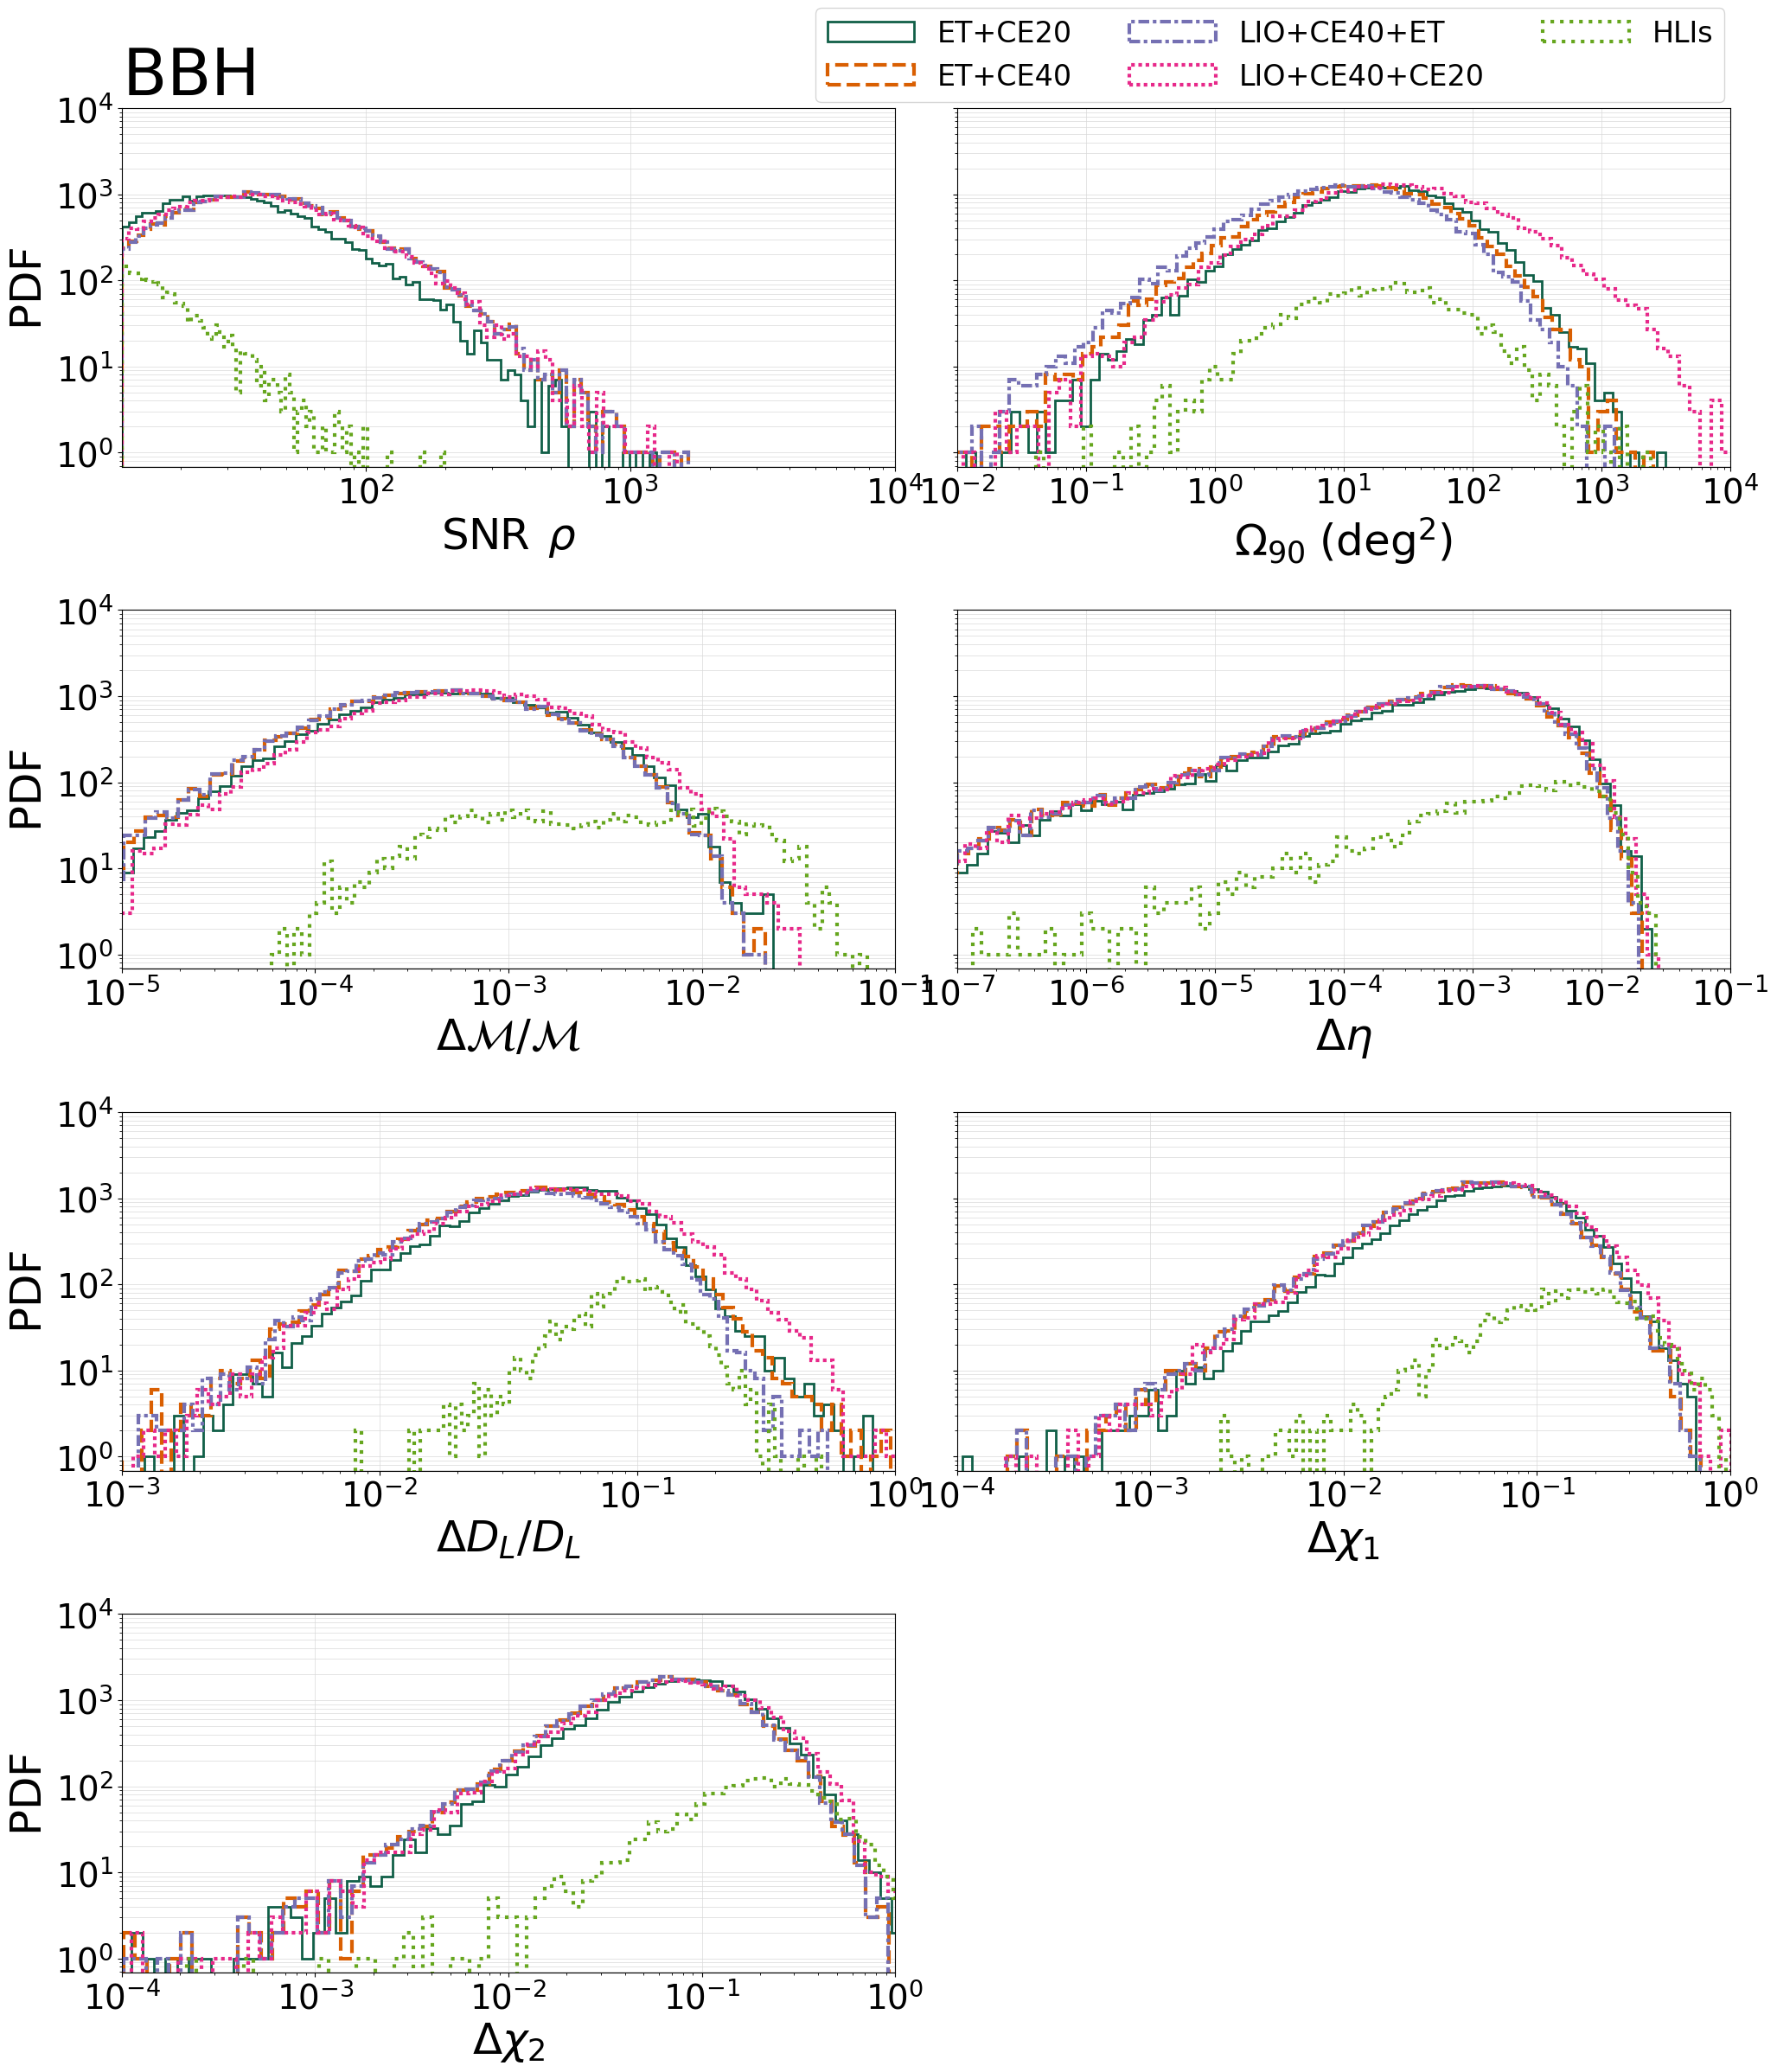

PDF done.


In [15]:
labels = {
    'snr': r'$\mathrm{SNR}\:\:\rho$',
    'sa90': r'$\Omega_{90}\;(\mathrm{deg}^2)$',
    'Mc': r'$\Delta\mathcal{M}/\mathcal{M}$',
    'eta': r'$\Delta\eta$',
    'DL': r'$\Delta D_L / D_L$',
    'chi1z': r'$\Delta\chi_1$',
    'chi2z': r'$\Delta\chi_2$',
    'LambdaTilde': r'$\Delta\tilde{\Lambda}$',
    'deltaLambda': r'$\Delta\delta\Lambda$',
}


if CBC_type == 'BBH':
    keys = ['snr', 'sa90', 'Mc', 'eta', 'DL', 'chi1z', 'chi2z']
    row_num = 4; col_num = 2
    figsize = (24, 28)
elif CBC_type in ('NSBH', 'BNS'):
    keys = ['snr', 'sa90', 'Mc', 'eta', 'DL', 'LambdaTilde', 'deltaLambda']
    row_num = 4; col_num = 2
    figsize = (24, 28)

fig = plt.figure(figsize=(24, 28))
fig.subplots_adjust(wspace=0.08, hspace=0.4)
axes = fig.subplots(nrows=row_num, ncols=col_num, sharex=False, sharey=True)

# Hide empty panels
n_panels = row_num * col_num
for k in range(len(keys), n_panels):
    axes.flat[k].set_visible(False)

labelsize = 36
titlesize = 54
ticksize = 28
legendsize = 24

keys = ['snr', 'sa90', 'Mc', 'eta', 'DL', 'chi1z', 'chi2z']

for num_net, net in enumerate(networks):
    # Build data dictionary for a network
    data = {
        'snr': snr_pop[net],
        'sa90': sa90_pop[net],
        'Mc': logMc_pop[net],
        'eta': erreta_pop[net],
        'DL': logDL_pop[net],
        'chi1z': errchi1z_pop[net],
        'chi2z': errchi2z_pop[net],
    }
    if CBC_type in ('NSBH', 'BNS'):
        data['LambdaTilde'] = errLambdaTilde_pop[net]
        data['deltaLambda'] = errdeltaLambda_pop[net]

    for key in keys:
        dat = data[key]
        if len(dat) == 0:
            continue

        nrow = keys.index(key) // col_num
        ncol = keys.index(key) % col_num
        ax = axes[nrow, ncol]
        ax.set_axisbelow(True)

        if key == 'snr':
            ax.axvspan(1e-2, 1e1, facecolor='dimgrey', alpha=0.2)

        data_sample = np.sort(dat, kind='mergesort')
        data_sample = data_sample[data_sample > 0]
        if len(data_sample) == 0:
            continue

        ndata_bins = 80
        bin_e, bin_m = get_log_binning_for_sample(data_sample, ndata_bins)
        if lss[num_net] == '-':
            lw = 2
        else:
            lw = 3
        ax.hist(data_sample, bins=bin_e, color=plot_colors[num_net],
                histtype='step', ls=lss[num_net], lw=lw, label=net_labs[num_net])

        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlabel(labels[key], fontsize=labelsize)

        if not ncol:
            ax.set_ylabel(r'$\mathrm{PDF}$', fontsize=labelsize)

        ax.tick_params(axis='x', which='major', labelsize=ticksize)
        ax.tick_params(axis='y', which='both', labelsize=ticksize)
        ax.set_yticks([1e0, 1e1, 1e2, 1e3, 1e4])
        ax.xaxis.grid(True, which='major', color='0.85', linestyle='-', linewidth=0.5)
        ax.yaxis.grid(True, which='both', color='0.85', linestyle='-', linewidth=0.5)

        if not nrow and ncol:
            ax.legend(bbox_to_anchor=(1, 1), loc=4, ncol=3,
                      borderaxespad=0.2, fontsize=legendsize, handlelength=3)
        if not nrow and not ncol:
            ax.set_title(f'$\\mathrm{{{CBC_type}}}$', fontsize=titlesize, loc='left')

        if CBC_type == 'BBH':
            if key == 'snr':     ax.set_xlim((12, 1e4))
            elif key == 'sa90':  ax.set_xlim((1e-2, 1e4))
            elif key == 'Mc':    ax.set_xlim((1e-5, 1e-1))
            elif key == 'eta':   ax.set_xlim((1e-7, 1e-1))
            elif key == 'DL':    ax.set_xlim((1e-3, 1e0))
            elif key == 'chi1z': ax.set_xlim((1e-4, 1e0))
            elif key == 'chi2z': ax.set_xlim((1e-4, 1e0))
        elif CBC_type in ('NSBH', 'BNS'):
            if key == 'snr':     ax.set_xlim((12, 1e4))
            elif key == 'sa90':  ax.set_xlim((1e-2, 1e4))
            elif key == 'Mc':    ax.set_xlim((1e-5, 1e-1))
            elif key == 'eta':   ax.set_xlim((1e-6, 1e-1))
            elif key == 'DL':    ax.set_xlim((1e-3, 1e0))
            elif key == 'LambdaTilde': ax.set_xlim((1e-1, 1e4))
            elif key == 'deltaLambda': ax.set_xlim((1e-1, 1e4))

plt.savefig(os.path.join(outdir, f'{CBC_type}_PDF_histograms.pdf'), bbox_inches='tight')
plt.show()
plt.close()
print('PDF done.')

**CDFs**

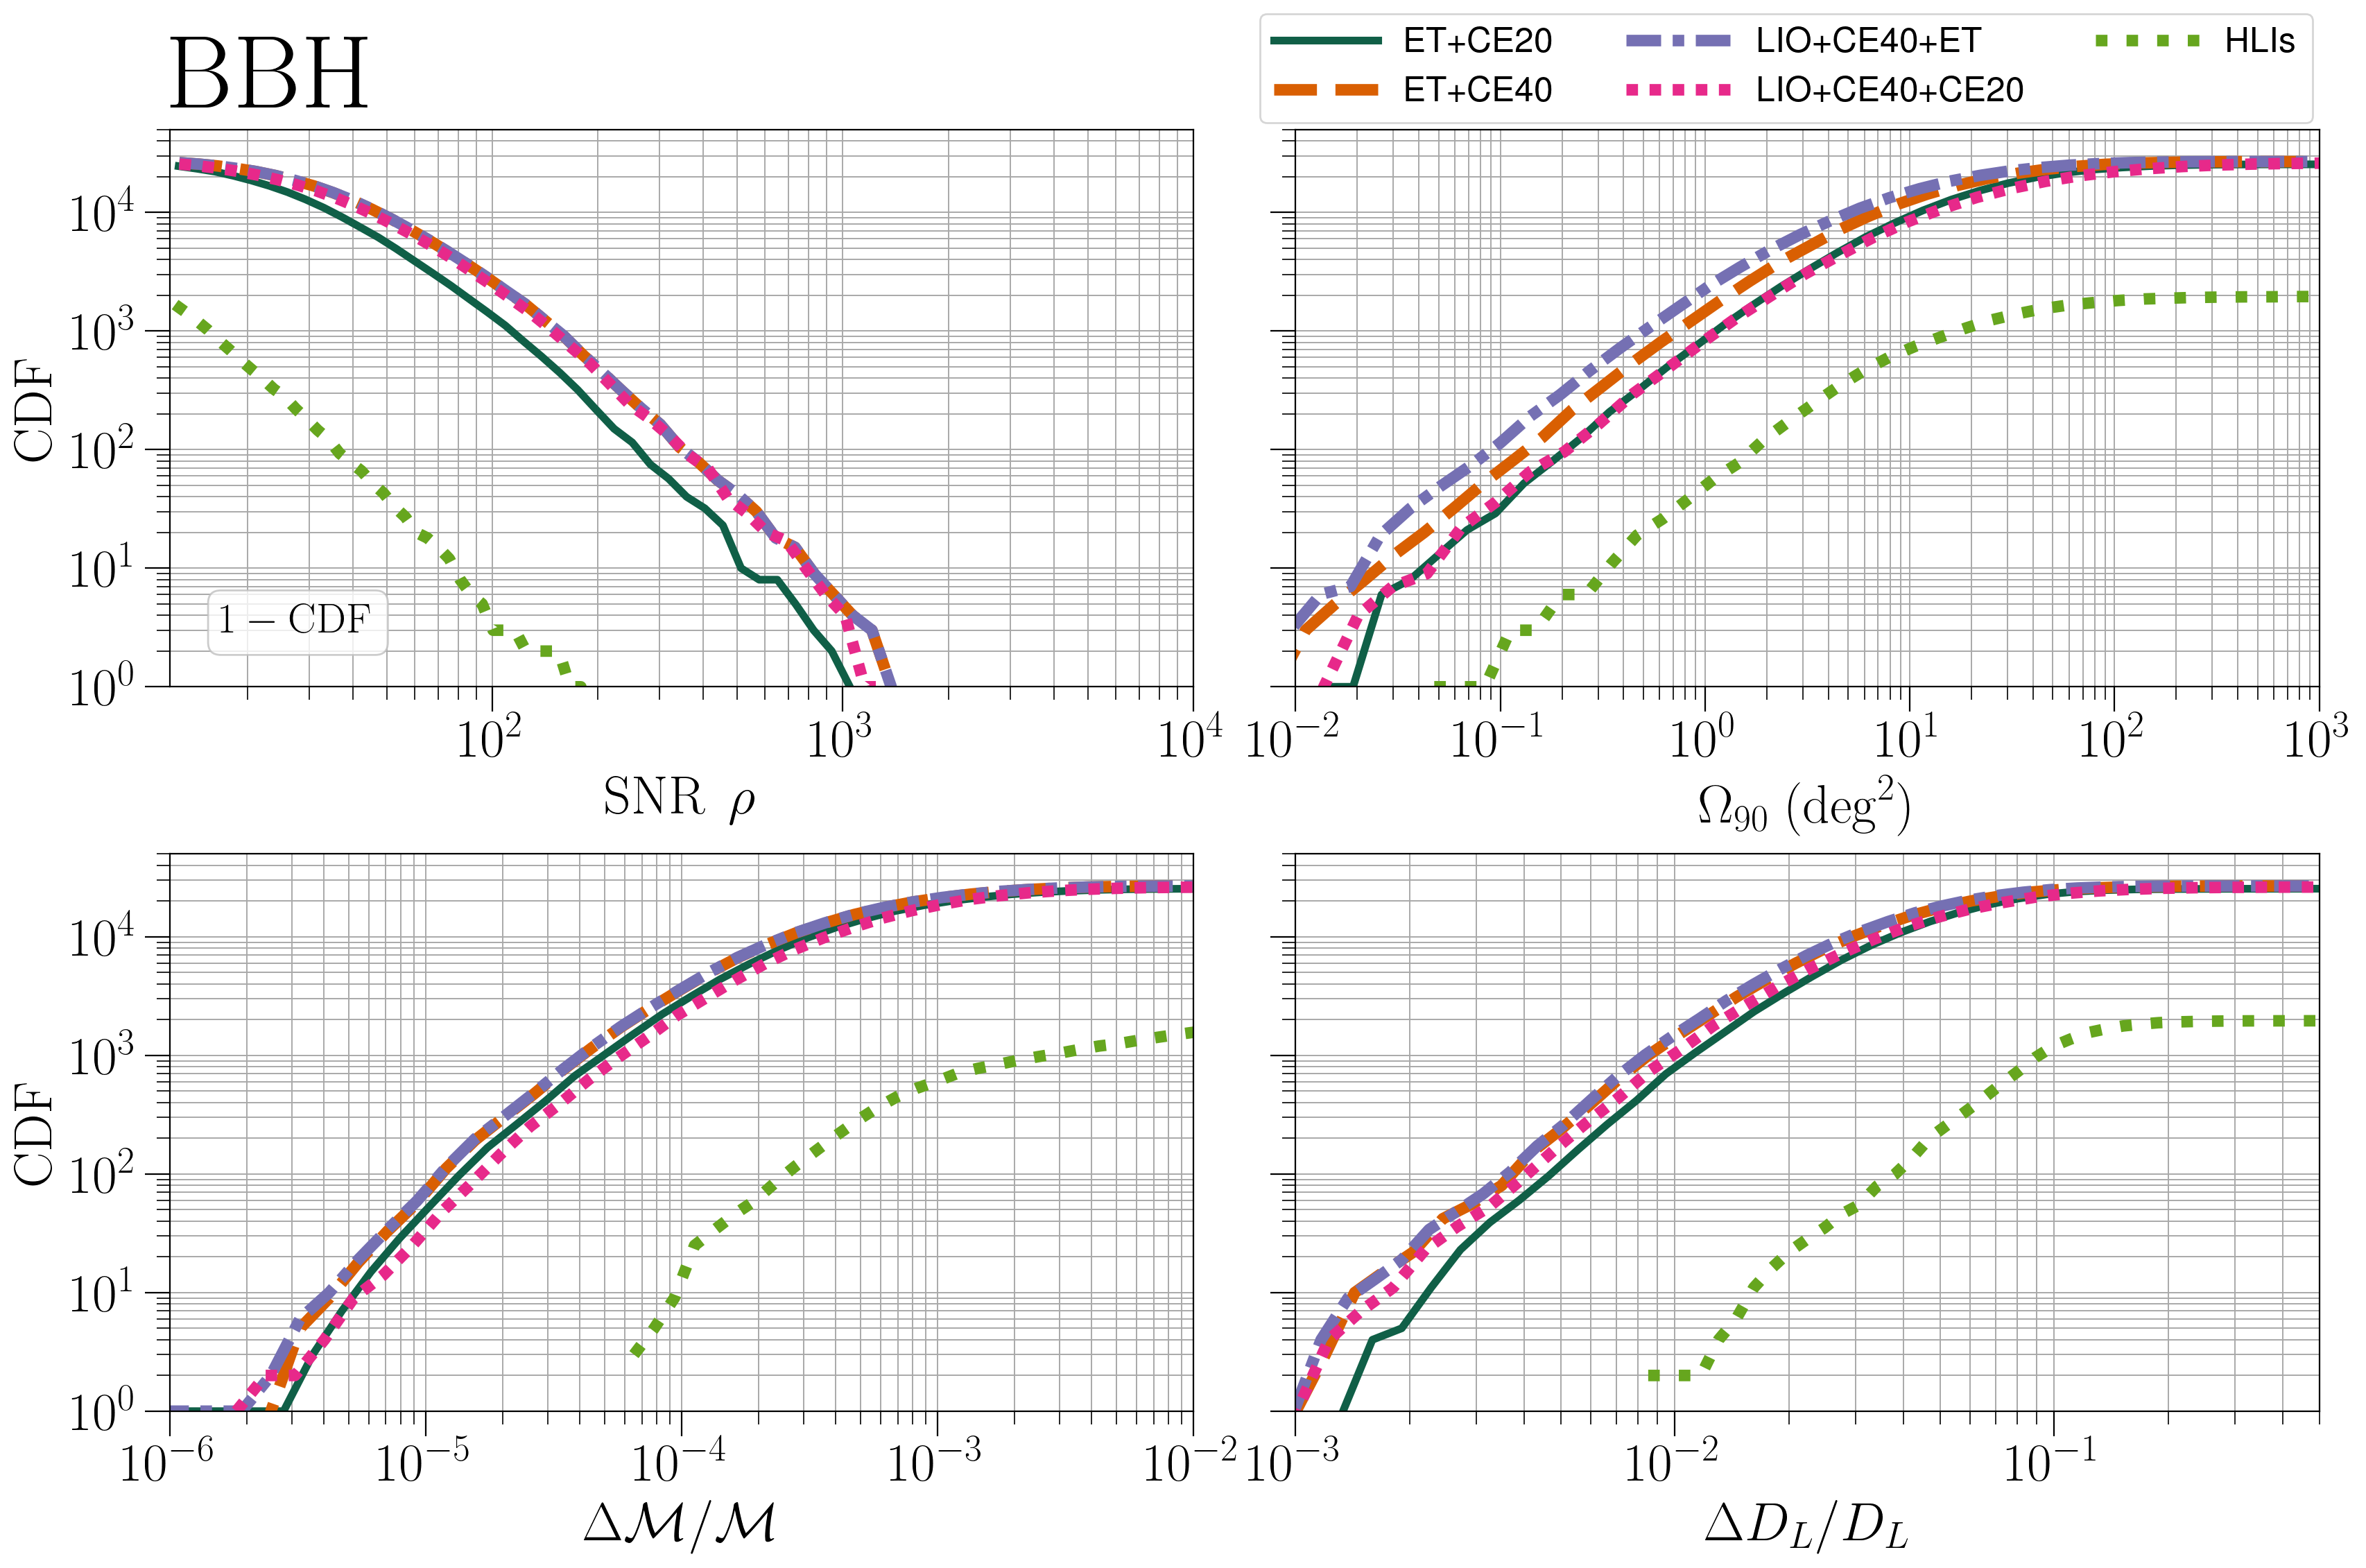

CDF done.


In [16]:
cdf_keys = ['snr', 'sa90', 'Mc', 'DL']
cdf_labels = {
    'snr': r'$\mathrm{SNR}\:\:\rho$',
    'sa90': r'$\Omega_{90}\;(\mathrm{deg}^2)$',
    'Mc': r'$\Delta\mathcal{M}/\mathcal{M}$',
    'DL': r'$\Delta D_L / D_L$',
}

matplotlib.rcParams.update({
    "font.size": 14.0,
    "font.family": 'sans-serif',
    "font.sans-serif": ['Helvetica'],
    "axes.titlesize": 20.0,
    "axes.labelsize": 22.0,
    "xtick.labelsize": 16.0,
    "ytick.labelsize": 16.0,
    "xtick.major.size": 13.0,
    "ytick.major.size": 13.0,
    "xtick.minor.size": 7.0,
    "ytick.minor.size": 7.0,
    "legend.fontsize": 12.0,
    "figure.dpi": 200,
    "savefig.dpi": 450,
    "text.usetex": True
})

fig = plt.figure(figsize=(20, 12))
fig.subplots_adjust(wspace=0.1, hspace=0.3)
row_num = 2
col_num = 2
axes = fig.subplots(nrows=row_num, ncols=col_num, sharex=False, sharey=True)

labelsize = 28
titlesize = 54
ticksize = 28
legendsize = 18

for i, key in enumerate(cdf_keys):
    nrow = i // col_num
    ncol = i % col_num
    ax = axes[nrow, ncol]
    ax.set_axisbelow(True)

    if key == 'snr':
        ax.axvspan(1e0, 1e1, facecolor='dimgrey', alpha=0.2)
        ax.text(0.05, 0.08, r'$1-\mathrm{CDF}$', fontsize=22,
                horizontalalignment='left', verticalalignment='bottom',
                bbox=dict(boxstyle="round", ec='silver', fc='w', alpha=0.8),
                transform=ax.transAxes)

    for num_net, net in enumerate(networks):
        if key == 'snr':
            dat = snr_pop[net]
        elif key == 'sa90':
            dat = sa90_pop[net]
        elif key == 'Mc':
            dat = logMc_pop[net]
        elif key == 'DL':
            dat = logDL_pop[net]

        dat = np.array(dat)
        dat = dat[dat > 0]
        if len(dat) == 0:
            continue

        data_sample = np.sort(dat, kind='mergesort')
        ndata_bins = 40
        bin_e, bin_m = get_log_binning_for_sample(data_sample, ndata_bins)
        sample_hist, _ = np.histogram(data_sample, bins=bin_e)
        cdf = np.cumsum(sample_hist)
        if key == 'snr':
            cdf = np.amax(np.cumsum(sample_hist)) - cdf

        if lss[num_net] == '-':
            lw = 4
        else:
            lw = 6
        ax.plot(bin_m, cdf, color=plot_colors[num_net], linestyle=lss[num_net],
                linewidth=lw, label=net_labs[num_net])

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(cdf_labels[key], fontsize=labelsize)

    if not ncol:
        ax.set_ylabel(r'$\mathrm{CDF}$', fontsize=labelsize)

    ax.tick_params(axis='x', which='major', labelsize=ticksize)
    ax.tick_params(axis='y', which='both', labelsize=ticksize)
    ax.xaxis.grid(True, which='both', color='darkgrey', linestyle='-', linewidth=0.7)
    ax.yaxis.grid(True, which='both', color='darkgrey', linestyle='-', linewidth=0.7)

    ax.set_ylim((1, 5e4))

    if not nrow and ncol:
        ax.legend(bbox_to_anchor=(1, 1), loc=4, ncol=3,
                  borderaxespad=0.2, fontsize=legendsize, handlelength=3)
    if not nrow and not ncol:
        ax.set_title(f'$\\mathrm{{{CBC_type}}}$', fontsize=titlesize, loc='left')

    if CBC_type == 'BBH':
        if key == 'snr':    ax.set_xlim((12, 1e4))
        elif key == 'sa90': ax.set_xlim((1e-2, 1e3))
        elif key == 'Mc':   ax.set_xlim((1e-6, 1e-2))
        elif key == 'DL':   ax.set_xlim((1e-3, 5e-1))
    # elif CBC_type == 'NSBH':
    #     if key == 'snr':    ax.set_xlim((12, 1e4))
    #     elif key == 'sa90': ax.set_xlim((1e-2, 1e4))
    #     elif key == 'Mc':   ax.set_xlim((1e-5, 1e-1))
    #     elif key == 'DL':   ax.set_xlim((1e-3, 1e0))

plt.savefig(os.path.join(outdir, f'{CBC_type}_CDFs_snr_sa90_Mc_DL.pdf'), bbox_inches='tight')
plt.show()
plt.close()
print('CDF done.')

**Detection Efficienty and Cumulative Detections**

Computing detection efficiency for ET_CE20...
Computing detection efficiency for ET_CE40...
Computing detection efficiency for LIO_CE40_ET...
Computing detection efficiency for LIO_CE40_CE20...
Computing detection efficiency for HLIs...


/tmp/ipykernel_2152851/3385761093.py:2: RuntimeWarning: invalid value encountered in power
  return ((1.0 + b) / (1.0 + b * np.exp(a*x)))**c
/tmp/ipykernel_2152851/3385761093.py:2: RuntimeWarning: overflow encountered in exp
  return ((1.0 + b) / (1.0 + b * np.exp(a*x)))**c


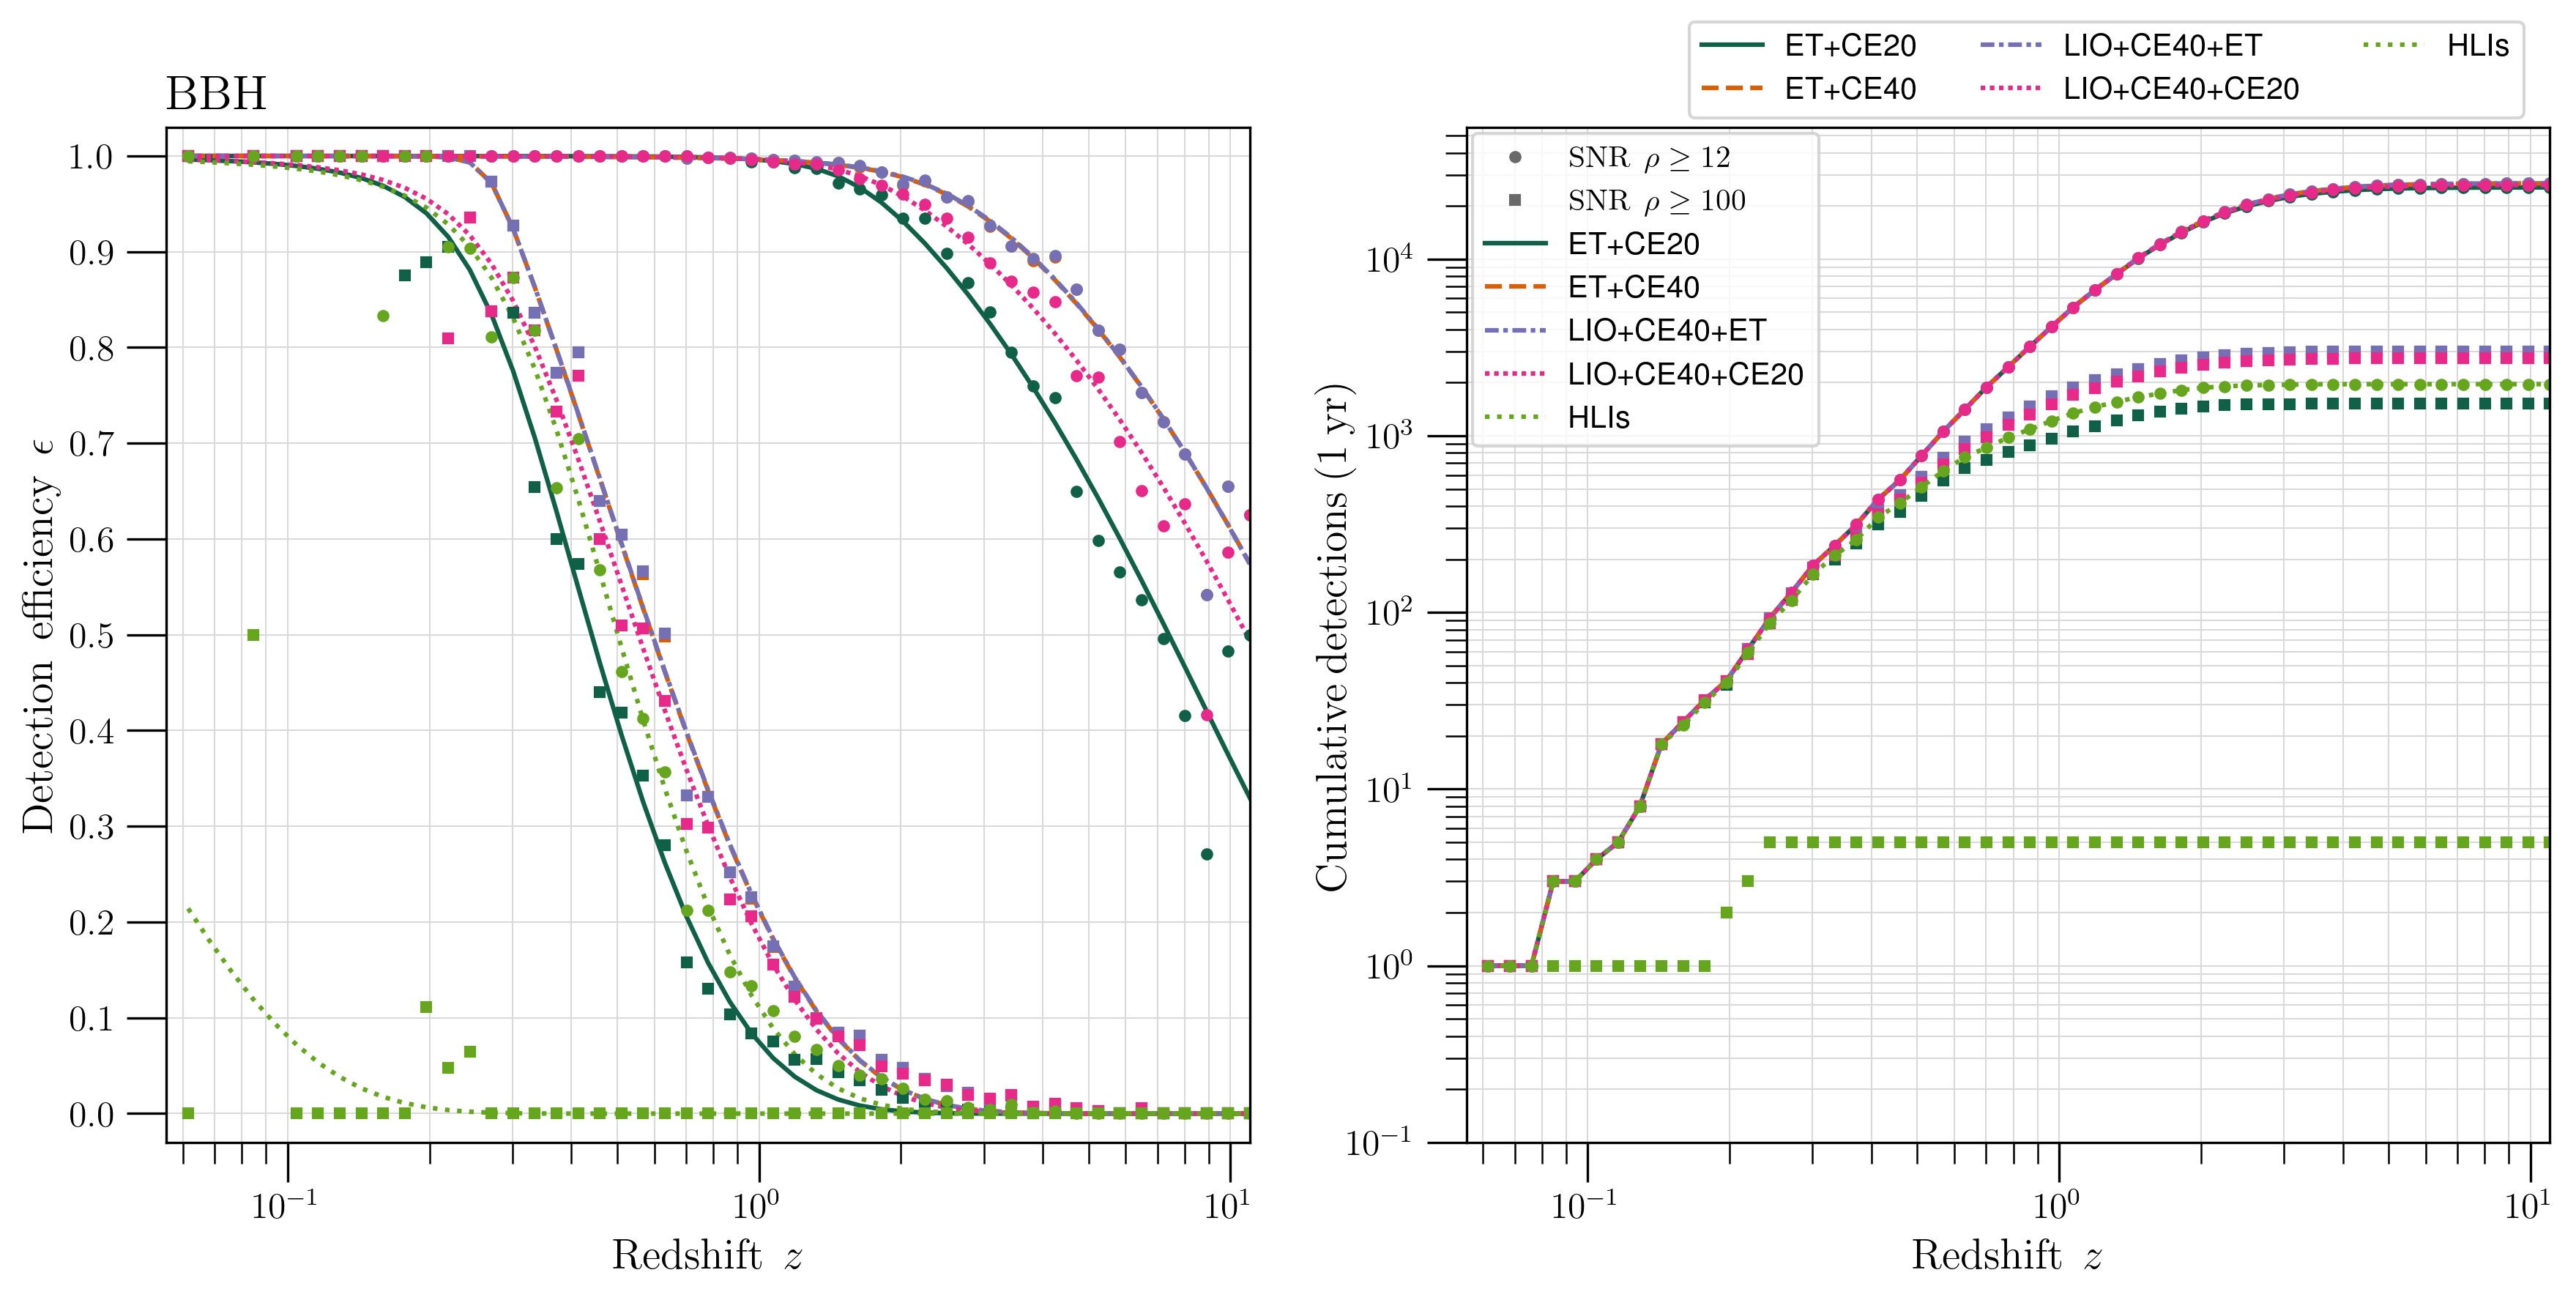

ET_CE20: 25475 detections (SNR>12), 1517 (SNR>100)
ET_CE40: 26857 detections (SNR>12), 2997 (SNR>100)
LIO_CE40_ET: 26870 detections (SNR>12), 3003 (SNR>100)
LIO_CE40_CE20: 26312 detections (SNR>12), 2747 (SNR>100)
HLIs: 1960 detections (SNR>12), 5 (SNR>100)
Total in catalog: 27929
Detection plot done.


In [17]:
def fsigmoid(x, a, b, c):
    return ((1.0 + b) / (1.0 + b * np.exp(a*x)))**c

low_snr = snr_lo
high_snr = 100

z_all_events = full_params[networks[0]]['inj_params']['z']
zlo = z_all_events.min() * 0.9
zhi = z_all_events.max() * 1.1

num_bins = 50
zs_bins = np.logspace(np.log10(zlo), np.log10(zhi), num_bins+1)

frac_100 = np.zeros((len(networks), num_bins))
frac_10 = np.zeros_like(frac_100)
count_10 = np.zeros_like(frac_100)
count_100 = np.zeros_like(frac_100)
count_all = np.zeros(num_bins)

for i in range(num_bins):
    bin_mask = np.logical_and(z_all_events >= zs_bins[i], z_all_events < zs_bins[i+1])
    count_all[i] = bin_mask.sum()

for num_net, net in enumerate(networks):
    print(f'Computing detection efficiency for {net}...')
    zs_all = full_params[net]['inj_params']['z']
    snrs_all = full_params[net]['net_data']['snr']

    for i in range(num_bins):
        bin_ids = np.nonzero(np.logical_and(zs_all >= zs_bins[i], zs_all < zs_bins[i+1]))[0]
        SNRS = snrs_all[bin_ids]
        if not SNRS.size:
            continue
        frac_100[num_net, i] = len(np.nonzero(SNRS > high_snr)[0]) / len(SNRS)
        frac_10[num_net, i] = len(np.nonzero(SNRS > low_snr)[0]) / len(SNRS)
        count_10[num_net, i] = len(np.nonzero(SNRS > low_snr)[0])
        count_100[num_net, i] = len(np.nonzero(SNRS > high_snr)[0])

zs_plot = zs_bins[1:]
valid = count_all > 0

matplotlib.rcParams.update({
    "font.size": 12.0,
    "font.family": 'sans-serif',
    "font.sans-serif": ['Helvetica'],
    "axes.titlesize": 12.0,
    "axes.labelsize": 12.0,
    "xtick.labelsize": 12.0,
    "ytick.labelsize": 12.0,
    "xtick.major.size": 13.0,
    "ytick.major.size": 13.0,
    "xtick.minor.size": 7.0,
    "ytick.minor.size": 7.0,
    "legend.fontsize": 10.0,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "text.usetex": True
})

fig = plt.figure(figsize=(14, 6))
fig.subplots_adjust(wspace=0.2)
axes_dr = fig.subplots(nrows=1, ncols=2, sharex=True, sharey=False)

labelsize = 14
ticksize = 12
titlesize = 20
ms = 3

# ── LEFT PANEL: Detection efficiency ──
ax = axes_dr[0]

fit_10 = []
fit_100 = []

for num_net, net in enumerate(networks):
    try:
        popt_10, _ = sciop.curve_fit(fsigmoid, zs_plot[valid], frac_10[num_net][valid],
                                      method='dogbox', maxfev=5000)
        fit_10.append(fsigmoid(zs_plot, *popt_10))
    except:
        fit_10.append(None)
    try:
        popt_100, _ = sciop.curve_fit(fsigmoid, zs_plot[valid], frac_100[num_net][valid],
                                       method='dogbox', maxfev=5000)
        fit_100.append(fsigmoid(zs_plot, *popt_100))
    except:
        fit_100.append(None)

# Sigmoid fits: SNR>100 without label, SNR>snr_lo with label
for num_net, net in enumerate(networks):
    if fit_100[num_net] is not None:
        ax.plot(zs_plot, fit_100[num_net], ls=lss[num_net], color=plot_colors[num_net])
for num_net, net in enumerate(networks):
    if fit_10[num_net] is not None:
        ax.plot(zs_plot, fit_10[num_net], ls=lss[num_net], color=plot_colors[num_net],
                label=net_labs[num_net])
        
# Data points: circles = SNR>snr_lo, squares = SNR>100
for num_net, net in enumerate(networks):
    ax.plot(zs_plot[valid], frac_100[num_net][valid], 's', ms=ms, color=plot_colors[num_net])
for num_net, net in enumerate(networks):
    ax.plot(zs_plot[valid], frac_10[num_net][valid], 'o', ms=ms, color=plot_colors[num_net])

ax.set_xscale('log')
ax.set_xlim((zlo, zhi))
ax.xaxis.grid(True, which='both', color='0.85', linestyle='-', linewidth=0.5)
ax.yaxis.grid(True, which='both', color='0.85', linestyle='-', linewidth=0.5)

ypos = np.linspace(0, 1, 11)
ylab = [r'$%.1f$' % y for y in ypos]
ax.set_yticks(ypos)
ax.set_yticklabels(ylab)
for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontsize(ticksize)

ax.set_ylabel(r'$\mathrm{Detection \:\: efficiency} \:\: \epsilon$', fontsize=labelsize, labelpad=3)
ax.set_ylim((-0.03, 1.03))
ax.set_xlabel(r'$\mathrm{Redshift}\:\:z$', fontsize=labelsize)
ax.legend(bbox_to_anchor=(1.4, 1.11), loc=2, ncol=3, borderaxespad=0.2)
ax.set_title(f'$\\mathrm{{{CBC_type}}}$', fontsize=titlesize*0.8, loc='left')

# ── RIGHT PANEL: Cumulative detections ──
ax = axes_dr[1]

ax.plot([], [], 'o', ms=ms, color='dimgrey',
        label=r'$\mathrm{SNR}\:\:\rho\geq%i$' % low_snr)
ax.plot([], [], 's', ms=ms, color='dimgrey',
        label=r'$\mathrm{SNR}\:\:\rho\geq%i$' % high_snr)

for num_net, net in enumerate(networks):
    cum_10 = np.cumsum(count_10[num_net])
    cum_100 = np.cumsum(count_100[num_net])
    ax.plot(zs_plot, cum_10, 'o', ms=ms, color=plot_colors[num_net])
    ax.plot(zs_plot, cum_100, 's', ms=ms, color=plot_colors[num_net])
    ax.plot(zs_plot, cum_10, ls=lss[num_net], color=plot_colors[num_net],
            lw=1.5, label=net_labs[num_net])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim((zlo, zhi))
ax.set_ylim((1e-1, num_inj * 2))
ax.set_xlabel(r'$\mathrm{Redshift}\:\:z$', fontsize=labelsize)
ax.set_ylabel(r'$\mathrm{Cumulative\: detections\: (1\: yr)}$',
               fontsize=labelsize, labelpad=-3)
ax.xaxis.grid(True, which='both', color='0.85', linestyle='-', linewidth=0.5)
ax.yaxis.grid(True, which='both', color='0.85', linestyle='-', linewidth=0.5)
ax.legend(bbox_to_anchor=(0, 1), loc=2, ncol=1, borderaxespad=0.2)

plt.savefig(os.path.join(outdir, f'{CBC_type}_det_eff_rate.pdf'), bbox_inches='tight', facecolor='w')
plt.show()
plt.close()

for num_net, net in enumerate(networks):
    print(f'{net}: {int(np.sum(count_10[num_net]))} detections (SNR>{low_snr}), '
          f'{int(np.sum(count_100[num_net]))} (SNR>{high_snr})')
print(f'Total in catalog: {num_inj}')
print('Detection plot done.')


**Redishift Distribution for Different Sky Area Thresholds**

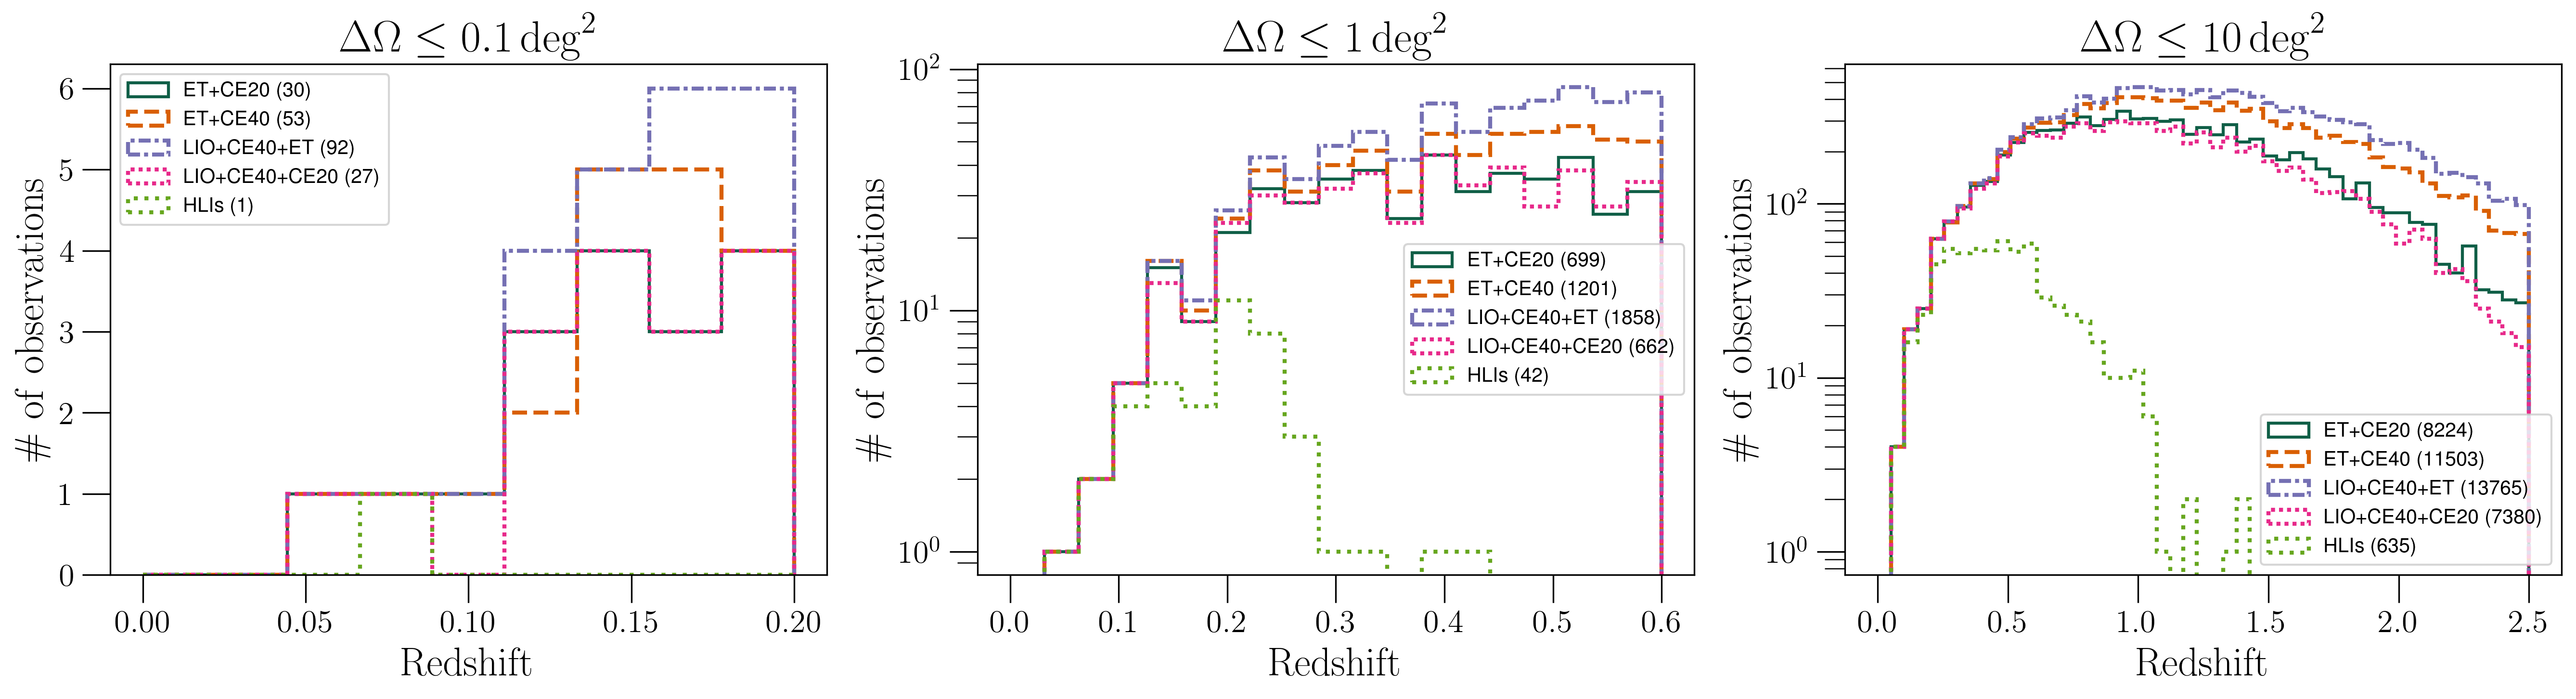

Sky area plots done.


In [18]:
matplotlib.rcParams.update({
    "font.size": 12.0,
    "font.family": 'sans-serif',
    "font.sans-serif": ['Helvetica'],
    "axes.titlesize": 24.0,
    "axes.labelsize": 20.0,
    "xtick.labelsize": 16.0,
    "ytick.labelsize": 16.0,
    "xtick.major.size": 14.0,
    "ytick.major.size": 14.0,
    "xtick.minor.size": 10.0,
    "ytick.minor.size": 10.0,
    "legend.fontsize": 14.0,
    "figure.dpi": 300,
    "savefig.dpi": 450,
    "text.usetex": True
})

sa_cuts = [0.1, 1, 10]
sa_bins = [np.linspace(0, 0.2, 10), np.linspace(0, 0.6, 20), np.linspace(0, 2.5, 50)]
sa_titles = [r'$\Delta\Omega \leq 0.1\,\mathrm{deg}^2$',
             r'$\Delta\Omega \leq 1\,\mathrm{deg}^2$',
             r'$\Delta\Omega \leq 10\,\mathrm{deg}^2$']

fig, axes_sa = plt.subplots(1, 3, figsize=(18, 5))
fig.subplots_adjust(wspace=0.3)

for j in range(3):
    ax = axes_sa[j]
    for num_net, net in enumerate(networks):
        z_cut = z_inj[net][sa90_pop[net] <= sa_cuts[j]]
        if len(z_cut) == 0:
            continue
        if lss[num_net] == '-':
            lw = 1.5
        else:
            lw = 2
        ax.hist(z_cut, bins=sa_bins[j], histtype='step',
                color=plot_colors[num_net], ls=lss[num_net], lw=lw,
                label=f'{net_labs[num_net]} ({len(z_cut)})')
    ax.set_ylabel(r'$\mathrm{\#\,\,of\,\,observations}$')
    ax.set_xlabel(r'$\mathrm{Redshift}$')
    ax.set_title(sa_titles[j], fontsize=22)
    if j == 1 or j == 2:
        ax.set_yscale('log')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(outdir, f'{CBC_type}_skyarea_redshift.pdf'), bbox_inches='tight')
plt.show()
plt.close()
print('Sky area plots done.')



**SNR Distributions by Sky Area Threshold**

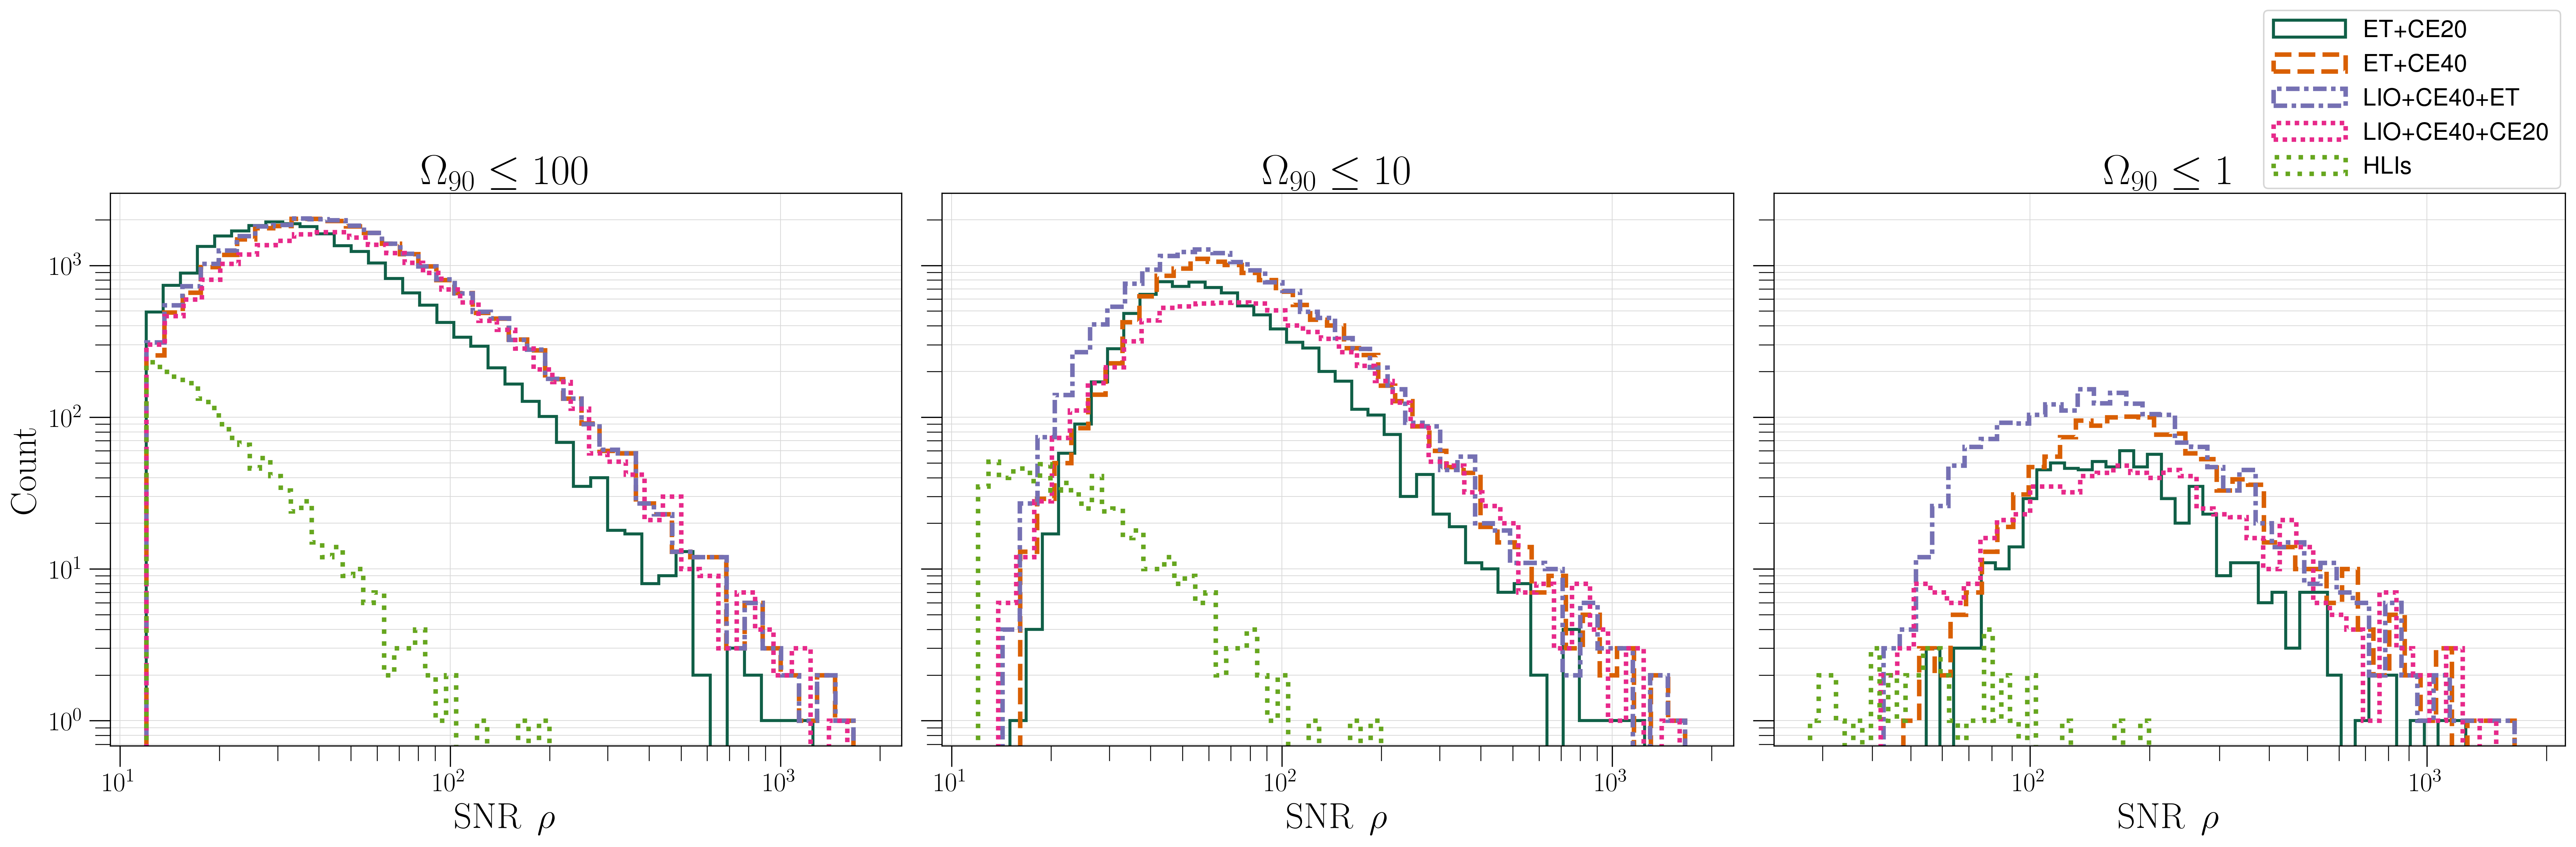

Done.


In [19]:
matplotlib.rcParams.update({
    "font.size": 12.0,
    "axes.titlesize": 32.0,
    "axes.labelsize": 24.0,
    "xtick.labelsize": 18.0,
    "ytick.labelsize": 18.0,
    "xtick.major.size": 14.0,
    "ytick.major.size": 14.0,
    "legend.fontsize": 24.0,
    "figure.dpi": 300,
    "savefig.dpi": 450,
    "text.usetex": True
})

sa_thresholds = [100, 10, 1]
sa_labels_plot = [r'$\Omega_{90} \leq 100$', r'$\Omega_{90} \leq 10$', r'$\Omega_{90} \leq 1$']

fig = plt.figure(figsize=(24, 8))
row_num = 1
col_num = 3
axes_snr = fig.subplots(nrows=row_num, ncols=col_num, sharex=False, sharey=True)

for num_net, net in enumerate(networks):
    for j, sa_th in enumerate(sa_thresholds):
        ax = axes_snr[j]
        ax.set_axisbelow(True)
        ax.set_xscale('log')

        mask = sa90_pop[net] <= sa_th
        snr_cut = snr_pop[net][mask]
        if len(snr_cut) == 0:
            continue

        ndata_bins = 40
        data_sample = np.sort(snr_cut)
        bin_e, bin_m = get_log_binning_for_sample(data_sample, ndata_bins)
        if lss[num_net] == '-':
            lw = 2
        else:
            lw = 3
        ax.hist(data_sample, bins=bin_e, color=plot_colors[num_net],
                histtype='step', ls=lss[num_net], lw=lw, label=net_labs[num_net])

        ax.set_xlabel(r'$\mathrm{SNR}\:\:\rho$', fontsize=24)
        ax.set_title(sa_labels_plot[j], fontsize=28)
        ax.set_yscale('log')
        ax.xaxis.grid(True, which='major', color='0.85', linestyle='-', linewidth=0.5)
        ax.yaxis.grid(True, which='both', color='0.85', linestyle='-', linewidth=0.5)

axes_snr[0].set_ylabel(r'$\mathrm{Count}$', fontsize=24)
axes_snr[2].legend(bbox_to_anchor=(1, 1), loc=4, ncol=1,
                    borderaxespad=0.2, fontsize=16, handlelength=3)

plt.tight_layout()
plt.savefig(os.path.join(outdir, f'{CBC_type}_SNR_by_skyarea.pdf'), bbox_inches='tight')
plt.show()
plt.close()
print('Done.')

